In [5]:
import yfinance as yf
import pandas as pd

In [6]:
# DataFetcher class to retrieve stock data
# This class takes a stock ticker, start date, and end date as input and uses the yfinance library to fetch historical stock data.
# The fetch_data method downloads the data and returns it as a DataFrame.
# Example usage:
# data_fetcher = DataFetcher('AAPL', '2020-01-01', '2021-01-01')

class DataFetcher:
    def __init__(self, ticker, start_date, end_date):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date

    def fetch_data(self):
        data = yf.download(self.ticker, start=self.start_date, end=self.end_date)
        return data

In [7]:
# Get user input for stock ticker and date range
ticker = input("Enter the stock ticker (e.g., AAPL): ")
start_date = input("Enter the start date (YYYY-MM-DD): ")
end_date = input("Enter the end date (YYYY-MM-DD): ")
stock_data = DataFetcher(ticker, start_date, end_date).fetch_data()
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open      Volume
Ticker          NVDA      NVDA      NVDA      NVDA        NVDA
Date                                                          
1999-01-22  0.037605  0.044767  0.035575  0.040112  2714688000
1999-01-25  0.041545  0.042021  0.037605  0.040589   510480000
1999-01-26  0.038321  0.042857  0.037724  0.042021   343200000
1999-01-27  0.038202  0.039395  0.036291  0.038440   244368000
1999-01-28  0.038082  0.038440  0.037843  0.038202   227520000


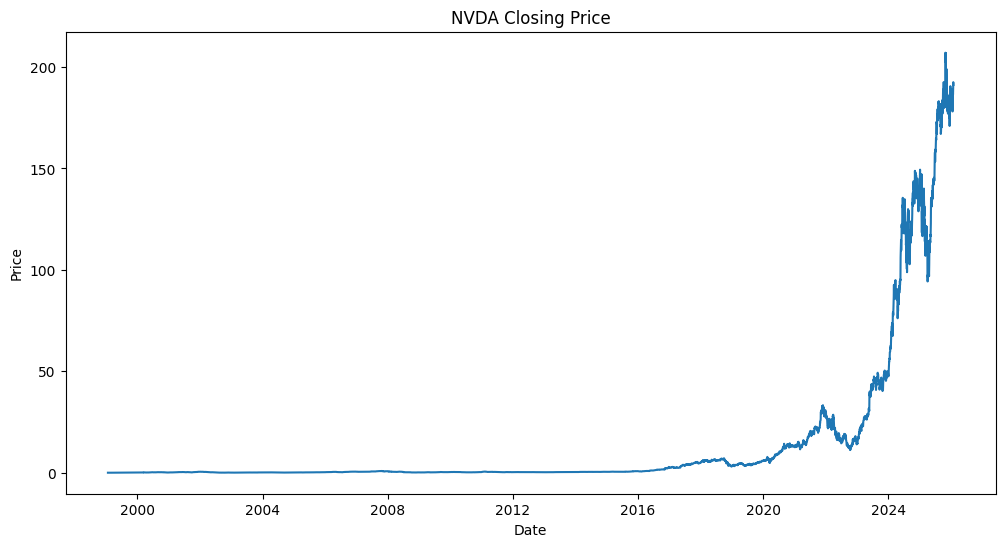

In [10]:
# Visualize the closing price
# This code uses the matplotlib library to create a line plot of the closing price of the stock over time. The x-axis represents the date, and the y-axis represents the closing price. The plot is displayed using plt.show().
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'])
plt.title(f'{ticker} Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [12]:
# Set device for PyTorch
# This code checks if a GPU is available and sets the device accordingly. If a GPU is available, it will use 'cuda'; otherwise, it will fall back to 'cpu'. This allows the code to take advantage of GPU acceleration if possible.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
# Preprocess the data
# This code uses the StandardScaler from scikit-learn to normalize the closing price data. Normalization is a common preprocessing step in machine learning that helps improve the performance of models by scaling the features to a standard range. The fit_transform method is used to fit the scaler to the data and then transform it in one step.
# Note: In a real implementation, you would typically want to fit the scaler on the training data and then transform both the training and test data separately to avoid data leakage. Here, for simplicity, we are applying it directly to the entire dataset.
scaler = StandardScaler()
stock_data['Close'] = scaler.fit_transform(stock_data['Close'])

# Create sequences for LSTM
# This code creates sequences of closing price data to be used as input for an LSTM model. The seq_length variable defines the length of each sequence (in this case, 60 time steps). The loop iterates through the stock data and appends sequences of closing prices to the data list. Each sequence consists of seq_length closing prices followed by the next closing price, which will be used as the target for prediction.

seq_length = 60
data = []

# Loop through the stock data and create sequences of closing prices

for i in range(len(stock_data) - seq_length):
    data.append(stock_data['Close'].values[i:i+seq_length])


[array([[-0.38152152],
        [-0.38141445],
        [-0.38150206],
        [-0.3815053 ],
        [-0.38150856],
        [-0.38155723],
        [-0.38153774],
        [-0.38161561],
        [-0.38159615],
        [-0.38154424],
        [-0.38151504],
        [-0.38155072],
        [-0.38158967],
        [-0.38159938],
        [-0.38151828],
        [-0.38145988],
        [-0.3814534 ],
        [-0.3815118 ],
        [-0.38149558],
        [-0.38145988],
        [-0.3814534 ],
        [-0.3814015 ],
        [-0.38131065],
        [-0.38134957],
        [-0.38140474],
        [-0.38139823],
        [-0.38140798],
        [-0.38148584],
        [-0.38150856],
        [-0.38145016],
        [-0.38143394],
        [-0.38139823],
        [-0.38141772],
        [-0.38146638],
        [-0.38148584],
        [-0.38144042],
        [-0.3814761 ],
        [-0.38146962],
        [-0.38145664],
        [-0.3814534 ],
        [-0.38148584],
        [-0.38155072],
        [-0.38155723],
        [-0